In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix: Truncate lines that split on stray quotes back to the standard 17 columns
df = pd.read_csv('sample_data/zomato.csv', engine='python', on_bad_lines=lambda line: line[:17])

print(f"Dataset loaded cleanly! Initial shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Dataset loaded cleanly! Initial shape: 51155 rows, 17 columns


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


In [18]:
# 1. Clean 'rate' column -> float
def clean_rate(val):
    if pd.isna(val) or str(val).strip() in ['NEW', '-']:
        return np.nan
    return float(str(val).split('/')[0].strip())

df['rate_clean'] = df['rate'].apply(clean_rate)

# 2. Clean 'approx_cost(for two people)' -> float
def clean_cost(val):
    if pd.isna(val):
        return np.nan
    return float(str(val).replace(',', '').strip())

df['approx_cost_clean'] = df['approx_cost(for two people)'].apply(clean_cost)

# 3. Clean 'votes' column -> int
df['votes'] = pd.to_numeric(df['votes'], errors='coerce').fillna(0).astype(int)

# 4. Impute missing text fields
df['dish_liked'] = df['dish_liked'].fillna('Not Specified')
df['cuisines'] = df['cuisines'].fillna('Not Specified')
df['rest_type'] = df['rest_type'].fillna('Not Specified')

# 5. Create Calculated Field: Cost Bracket
def categorize_cost(cost):
    if pd.isna(cost):
        return 'Unknown'
    elif cost < 300:
        return 'Budget (< ₹300)'
    elif cost <= 700:
        return 'Mid-Tier (₹300 - ₹700)'
    elif cost <= 1500:
        return 'Upper-Mid (₹700 - ₹1500)'
    else:
        return 'Premium (> ₹1500)'

df['cost_bracket'] = df['approx_cost_clean'].apply(categorize_cost)

# 6. Deduplicate restaurant entries
df_clean = df.drop_duplicates(subset=['name', 'address', 'location']).copy()

print(f"Cleaning complete! Processed shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Cleaning complete! Processed shape: 12518 rows, 20 columns


In [19]:
# Create clean export dataframe without heavy text blocks
df_display = df_clean.drop(columns=['reviews_list', 'url', 'menu_item'], errors='ignore')

# Save clean CSV for Google Sheets import
df_display.to_csv('Processed_Zomato_Data_Clean.csv', index=False)
print("Cleaned display dataset saved as 'Processed_Zomato_Data_Clean.csv'!")

Cleaned display dataset saved as 'Processed_Zomato_Data_Clean.csv'!


In [20]:
# EDA 1: Online Order vs Ratings & Votes (Q4 Insight 1)
print("--- 1. Online Delivery vs Offline Performance ---")
online_summary = df_clean.groupby('online_order').agg(
    avg_rating=('rate_clean', 'mean'),
    total_votes=('votes', 'sum'),
    restaurant_count=('name', 'count')
).reset_index()
print(online_summary)

print("\n--- 2. Performance Across Cost Brackets (Q5 Surprise) ---")
cost_summary = df_clean.groupby('cost_bracket').agg(
    avg_rating=('rate_clean', 'mean'),
    total_votes=('votes', 'sum'),
    restaurant_count=('name', 'count')
).reset_index()
print(cost_summary)

print("\n--- 3. Top 5 Micro-Markets by Vote Density (Q4 Insight 3) ---")
location_summary = df_clean.groupby('location').agg(
    total_votes=('votes', 'sum'),
    avg_rating=('rate_clean', 'mean'),
    restaurant_count=('name', 'count')
).sort_values(by='total_votes', ascending=False).head(5).reset_index()
print(location_summary)

--- 1. Online Delivery vs Offline Performance ---
  online_order  avg_rating  total_votes  restaurant_count
0           No    3.587424       845141              5899
1          Yes    3.648442      1403506              6619

--- 2. Performance Across Cost Brackets (Q5 Surprise) ---
               cost_bracket  avg_rating  total_votes  restaurant_count
0           Budget (< ₹300)    3.549516       137956              3209
1    Mid-Tier (₹300 - ₹700)    3.564889       826214              7382
2         Premium (> ₹1500)    4.147101       285053               283
3                   Unknown    3.509677         4912                60
4  Upper-Mid (₹700 - ₹1500)    3.858186       994512              1584

--- 3. Top 5 Micro-Markets by Vote Density (Q4 Insight 3) ---
                location  total_votes  avg_rating  restaurant_count
0            Indiranagar       253781    3.781839               533
1  Koramangala 5th Block       177297    3.908299               269
2             Whitefield

/tmp/ipykernel_1559/1367290977.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='cost_bracket', y='rate_clean', ci=None, palette='Blues_d')
/tmp/ipykernel_1559/1367290977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='cost_bracket', y='rate_clean', ci=None, palette='Blues_d')
/tmp/ipykernel_1559/1367290977.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='online_order', y='rate_clean', ci=None, palette='Set2')
/tmp/ipykernel_1559/1367290977.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean,

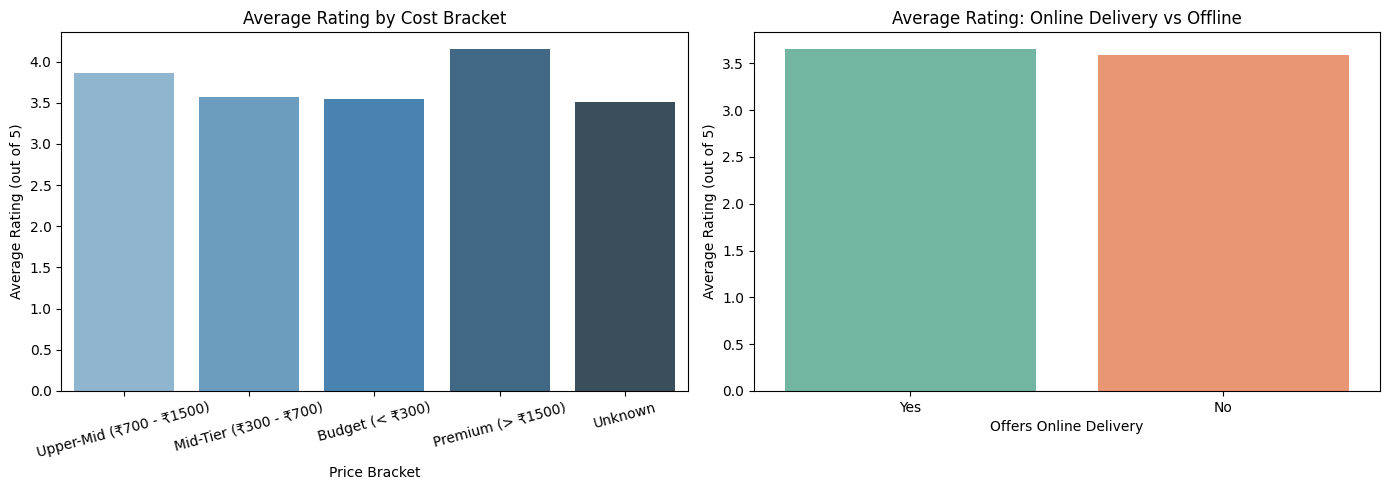

In [21]:
plt.figure(figsize=(14, 5))

# Chart 1: Average Rating by Price Bracket (Q5 Unexpected Finding)
plt.subplot(1, 2, 1)
sns.barplot(data=df_clean, x='cost_bracket', y='rate_clean', ci=None, palette='Blues_d')
plt.title('Average Rating by Cost Bracket')
plt.xlabel('Price Bracket')
plt.ylabel('Average Rating (out of 5)')
plt.xticks(rotation=15)

# Chart 2: Online Delivery vs Average Rating (Q4 Insight 1)
plt.subplot(1, 2, 2)
sns.barplot(data=df_clean, x='online_order', y='rate_clean', ci=None, palette='Set2')
plt.title('Average Rating: Online Delivery vs Offline')
plt.xlabel('Offers Online Delivery')
plt.ylabel('Average Rating (out of 5)')

plt.tight_layout()
plt.show()